# County-Level Mental Distress Prediction

## Objective

This notebook extends the original state-level mental-distress study to
the county level using the CDC PLACES County Data, 2025 release.

Counties will be identified using state abbreviation and CDC `LocationID`, avoiding the
county-name collisions present in the original exploratory analysis.
    

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
DATA_PATH = PROJECT_DIR / "data" / "places_county_2025.csv"

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Project directory: /Users/adi/Documents/Mental-Distress-Prediction
Dataset: /Users/adi/Documents/Mental-Distress-Prediction/data/places_county_2025.csv
Shape: 229,298 rows × 22 columns


,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,...,26.6,33.3,16945,13230,5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,...,9.2,11.9,12421,9795,5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,...,27.7,34.8,12533,9311,5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,...,4.2,5.3,42415,32396,5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,...,37.9,47.8,21793,16948,5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)


## 1. Initial Data Inspection

Before constructing the county-level dataset, we inspect the columns,
geographic identifiers, years, estimate types, missing values, and duplicate
records.

In [3]:
print("Columns:")
for column in df.columns:
    print(f"- {column}")

print("\nYears:", sorted(df["Year"].unique()))
print("\nData-value types:", df["Data_Value_Type"].unique())
print("\nNumber of states/territories:", df["StateAbbr"].nunique())
print("Number of location IDs:", df["LocationID"].nunique())
print("Number of location names:", df["LocationName"].nunique())

print("\nRows by estimate type:")
display(df["Data_Value_Type"].value_counts())

print("\nMissing values:")
display(
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(3)
    }).sort_values("missing_count", ascending=False)
)

Columns:
- Year
- StateAbbr
- StateDesc
- LocationName
- DataSource
- Category
- Measure
- Data_Value_Unit
- Data_Value_Type
- Data_Value
- Data_Value_Footnote_Symbol
- Data_Value_Footnote
- Low_Confidence_Limit
- High_Confidence_Limit
- TotalPopulation
- TotalPop18plus
- LocationID
- CategoryID
- MeasureId
- DataValueTypeID
- Short_Question_Text
- Geolocation

Years: [np.int64(2022), np.int64(2023)]

Data-value types: <ArrowStringArray>
['Crude prevalence', 'Age-adjusted prevalence']
Length: 2, dtype: str

Number of states/territories: 52
Number of location IDs: 3145
Number of location names: 1838

Rows by estimate type:


Data_Value_Type
Crude prevalence           114649
Age-adjusted prevalence    114649
Name: count, dtype: int64


Missing values:


,missing_count,missing_percent
Data_Value_Footnote,229218,99.965
Data_Value_Footnote_Symbol,229218,99.965
LocationName,80,0.035
Geolocation,80,0.035
High_Confidence_Limit,66,0.029
Data_Value,66,0.029
Low_Confidence_Limit,66,0.029
TotalPopulation,0,0.000
Short_Question_Text,0,0.000
DataValueTypeID,0,0.000


In [4]:
county_identifiers = (
    df[
        [
            "StateAbbr",
            "StateDesc",
            "LocationID",
            "LocationName",
            "TotalPopulation",
            "TotalPop18plus",
        ]
    ]
    .drop_duplicates()
    .sort_values(["StateAbbr", "LocationName"])
)

print(f"Unique geographic records: {len(county_identifiers):,}")
county_identifiers.head(10)

Unique geographic records: 3,145


,StateAbbr,StateDesc,LocationID,LocationName,TotalPopulation,TotalPop18plus
240,AK,Alaska,2013,Aleutians East,3461,3270
317,AK,Alaska,2016,Aleutians West,5160,4734
225,AK,Alaska,2020,Anchorage,286075,219385
241,AK,Alaska,2050,Bethel,18224,11798
223,AK,Alaska,2060,Bristol Bay,844,663
326,AK,Alaska,2063,Chugach,6769,5268
486,AK,Alaska,2066,Copper River,2674,1994
623,AK,Alaska,2068,Denali,1584,1291
253,AK,Alaska,2070,Dillingham,4607,3180
324,AK,Alaska,2090,Fairbanks North Star,94840,72305


In [5]:
repeated_names = (
    county_identifiers
    .groupby("LocationName")
    .agg(
        number_of_records=("LocationID", "size"),
        number_of_states=("StateAbbr", "nunique"),
        states=("StateAbbr", lambda values: ", ".join(sorted(set(values))))
    )
    .query("number_of_states > 1")
    .sort_values("number_of_states", ascending=False)
)

print(
    f"County names appearing in multiple states: "
    f"{len(repeated_names):,}"
)

repeated_names.head(20)

County names appearing in multiple states: 439


,number_of_records,number_of_states,states
LocationName,,,
Washington,31,31,"AL, AR, CO, FL, GA, IA, ID, IL, IN, KS, KY, LA..."
Jefferson,26,26,"AL, AR, CO, FL, GA, IA, ID, IL, IN, KS, KY, LA..."
Franklin,26,25,"AL, AR, FL, GA, IA, ID, IL, IN, KS, KY, LA, MA..."
Jackson,24,24,"AL, AR, CO, FL, GA, IA, IL, IN, KS, KY, LA, MI..."
Lincoln,24,24,"AR, CO, GA, ID, KS, KY, LA, ME, MN, MO, MS, MT..."
Madison,20,20,"AL, AR, FL, GA, IA, ID, IL, IN, KY, LA, MO, MS..."
Union,18,18,"AR, FL, GA, IA, IL, IN, KY, LA, MS, NC, NJ, NM..."
Clay,18,18,"AL, AR, FL, GA, IA, IL, IN, KS, KY, MN, MO, MS..."
Montgomery,18,18,"AL, AR, GA, IA, IL, IN, KS, KY, MD, MO, MS, NC..."


## 2. Study Measures and Geographic Coverage

The analysis uses depression prevalence and four indicators of financial
hardship to predict frequent mental distress. Before reshaping the data,
we examine each measure's year, state coverage, county coverage, and
missing values.

In [6]:
STUDY_MEASURES = {
    "depression": "Depression among adults",
    "housing": "Housing insecurity in the past 12 months among adults",
    "utility": "Utility services shut-off threat in the past 12 months among adults",
    "food": "Food insecurity in the past 12 months among adults",
    "stamps": "Received food stamps in the past 12 months among adults",
    "distress": "Frequent mental distress among adults",
}

for short_name, full_name in STUDY_MEASURES.items():
    print(f"{short_name:>10}: {full_name}")

depression: Depression among adults
   housing: Housing insecurity in the past 12 months among adults
   utility: Utility services shut-off threat in the past 12 months among adults
      food: Food insecurity in the past 12 months among adults
    stamps: Received food stamps in the past 12 months among adults
  distress: Frequent mental distress among adults


In [7]:
missing_location_rows = df[df["LocationName"].isna()]

print("Rows with missing LocationName:", len(missing_location_rows))
print(
    "State abbreviations:",
    missing_location_rows["StateAbbr"].unique()
)
print(
    "Location IDs:",
    missing_location_rows["LocationID"].unique()
)

display(
    missing_location_rows[
        [
            "Year",
            "StateAbbr",
            "StateDesc",
            "LocationID",
            "Measure",
            "Data_Value_Type",
            "Data_Value",
        ]
    ].head(10)
)

Rows with missing LocationName: 80
State abbreviations: <ArrowStringArray>
['US']
Length: 1, dtype: str
Location IDs: [59]


,Year,StateAbbr,StateDesc,LocationID,Measure,Data_Value_Type,Data_Value
218,2023,US,United States,59,Self-care disability among adults,Age-adjusted prevalence,3.4
640,2023,US,United States,59,Current lack of health insurance among adults ...,Crude prevalence,11.0
1151,2023,US,United States,59,Binge drinking among adults,Age-adjusted prevalence,16.6
1355,2023,US,United States,59,Cancer (non-skin) or melanoma among adults,Crude prevalence,7.9
1416,2023,US,United States,59,No leisure-time physical activity among adults,Crude prevalence,24.5
1758,2023,US,United States,59,Chronic obstructive pulmonary disease among ad...,Crude prevalence,6.2
2048,2023,US,United States,59,Fair or poor self-rated health status among ad...,Crude prevalence,19.2
2320,2023,US,United States,59,Lack of social and emotional support among adults,Age-adjusted prevalence,24.1
2360,2023,US,United States,59,Chronic obstructive pulmonary disease among ad...,Age-adjusted prevalence,5.3
2433,2023,US,United States,59,Lack of reliable transportation in the past 12...,Crude prevalence,7.7


In [8]:
county_long = df.loc[
    df["Measure"].isin(STUDY_MEASURES.values())
    & df["Data_Value_Type"].eq("Crude prevalence")
    & df["LocationName"].notna()
    & df["StateAbbr"].ne("US")
].copy()

print(f"Selected rows: {len(county_long):,}")
print(f"States/DC: {county_long['StateAbbr'].nunique()}")
print(f"Location IDs: {county_long['LocationID'].nunique():,}")
print(f"Measures: {county_long['Measure'].nunique()}")

Selected rows: 15,110
States/DC: 49
Location IDs: 2,957
Measures: 6


In [9]:
coverage = (
    county_long
    .groupby("Measure")
    .agg(
        years=("Year", lambda values: sorted(values.unique().tolist())),
        states=("StateAbbr", "nunique"),
        counties=("LocationID", "nunique"),
        available_values=("Data_Value", "count"),
        missing_values=("Data_Value", lambda values: values.isna().sum()),
    )
    .sort_values("counties", ascending=False)
)

coverage

,years,states,counties,available_values,missing_values
Measure,,,,,
Depression among adults,[2023],49,2957,2956,1
Frequent mental distress among adults,[2023],49,2957,2956,1
Food insecurity in the past 12 months among adults,[2023],40,2299,2299,0
Housing insecurity in the past 12 months among adults,[2023],40,2299,2299,0
Received food stamps in the past 12 months among adults,[2023],40,2299,2299,0
Utility services shut-off threat in the past 12 months among adults,[2023],40,2299,2299,0


In [10]:
state_coverage = (
    county_long
    .groupby("Measure")["StateAbbr"]
    .agg(lambda values: ", ".join(sorted(values.unique())))
)

for measure, states in state_coverage.items():
    print(f"\n{measure}")
    print(states)


Depression among adults
AK, AL, AR, AZ, CA, CO, CT, DC, DE, FL, GA, HI, IA, ID, IL, IN, KS, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, OR, RI, SC, SD, TN, TX, UT, VA, VT, WA, WI, WV, WY

Food insecurity in the past 12 months among adults
AK, AL, AR, AZ, CA, CT, DC, DE, GA, HI, IA, ID, IL, IN, KS, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, RI, SC, UT, VA, WI, WV

Frequent mental distress among adults
AK, AL, AR, AZ, CA, CO, CT, DC, DE, FL, GA, HI, IA, ID, IL, IN, KS, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, OR, RI, SC, SD, TN, TX, UT, VA, VT, WA, WI, WV, WY

Housing insecurity in the past 12 months among adults
AK, AL, AR, AZ, CA, CT, DC, DE, GA, HI, IA, ID, IL, IN, KS, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, RI, SC, UT, VA, WI, WV

Received food stamps in the past 12 months among adults
AK, AL, AR, AZ, CA, CT, DC, DE, GA, HI, IA, ID, IL, IN, KS, LA, 

In [11]:
duplicate_key = [
    "StateAbbr",
    "LocationID",
    "Year",
    "Measure",
    "Data_Value_Type",
]

duplicates = county_long.duplicated(
    subset=duplicate_key,
    keep=False
)

print(
    "Duplicate county-measure rows:",
    int(duplicates.sum())
)

if duplicates.any():
    display(
        county_long.loc[duplicates]
        .sort_values(duplicate_key)
        [duplicate_key + ["LocationName", "Data_Value"]]
        .head(20)
    )

Duplicate county-measure rows: 0


## 3. Construct the County-Level Analysis Table

The long-format CDC data are reshaped so that each row represents one
unique county and each study measure becomes a column.

The combined analysis is restricted to counties with observed values for
all predictors and the outcome. States without the CDC financial-hardship
measures are not mean-imputed.

In [12]:
county_wide = (
    county_long
    .pivot(
        index=[
            "StateAbbr",
            "StateDesc",
            "LocationID",
            "LocationName",
        ],
        columns="Measure",
        values="Data_Value",
    )
    .reset_index()
)

county_wide.columns.name = None

rename_map = {
    full_name: short_name
    for short_name, full_name in STUDY_MEASURES.items()
}

county_wide = county_wide.rename(columns=rename_map)

print(
    f"Wide dataset: {county_wide.shape[0]:,} counties "
    f"× {county_wide.shape[1]} columns"
)

county_wide.head()

Wide dataset: 2,957 counties × 10 columns


,StateAbbr,StateDesc,LocationID,LocationName,depression,food,distress,housing,stamps,utility
0,AK,Alaska,2013,Aleutians East,12.3,21.6,13.0,15.7,12.3,9.5
1,AK,Alaska,2016,Aleutians West,13.3,17.2,13.2,13.7,9.4,8.2
2,AK,Alaska,2020,Anchorage,21.3,12.8,16.1,11.9,9.0,7.8
3,AK,Alaska,2050,Bethel,21.0,37.6,21.6,26.8,29.7,19.5
4,AK,Alaska,2060,Bristol Bay,18.8,13.9,15.3,11.8,8.8,7.9


In [13]:
county_population = (
    county_long[
        [
            "StateAbbr",
            "LocationID",
            "TotalPopulation",
            "TotalPop18plus",
        ]
    ]
    .drop_duplicates()
)

population_key_duplicates = county_population.duplicated(
    subset=["StateAbbr", "LocationID"],
    keep=False,
)

print(
    "Counties with conflicting population records:",
    int(population_key_duplicates.sum())
)

Counties with conflicting population records: 0


In [14]:
county_wide = county_wide.merge(
    county_population,
    on=["StateAbbr", "LocationID"],
    how="left",
    validate="one_to_one",
)

county_wide.head()

,StateAbbr,StateDesc,LocationID,LocationName,depression,food,distress,housing,stamps,utility,TotalPopulation,TotalPop18plus
0,AK,Alaska,2013,Aleutians East,12.3,21.6,13.0,15.7,12.3,9.5,3461,3270
1,AK,Alaska,2016,Aleutians West,13.3,17.2,13.2,13.7,9.4,8.2,5160,4734
2,AK,Alaska,2020,Anchorage,21.3,12.8,16.1,11.9,9.0,7.8,286075,219385
3,AK,Alaska,2050,Bethel,21.0,37.6,21.6,26.8,29.7,19.5,18224,11798
4,AK,Alaska,2060,Bristol Bay,18.8,13.9,15.3,11.8,8.8,7.9,844,663


In [15]:
analysis_columns = [
    "depression",
    "housing",
    "utility",
    "food",
    "stamps",
    "distress",
]

missing_by_column = pd.DataFrame({
    "missing_count": county_wide[analysis_columns].isna().sum(),
    "missing_percent": (
        county_wide[analysis_columns].isna().mean() * 100
    ).round(2),
})

missing_by_column

,missing_count,missing_percent
depression,1,0.03
housing,658,22.25
utility,658,22.25
food,658,22.25
stamps,658,22.25
distress,1,0.03


In [16]:
county_wide.loc[
    county_wide[["depression", "distress"]].isna().any(axis=1),
    [
        "StateAbbr",
        "StateDesc",
        "LocationID",
        "LocationName",
        "depression",
        "distress",
    ],
]

,StateAbbr,StateDesc,LocationID,LocationName,depression,distress
2488,TX,Texas,48301,Loving,NaN,NaN


In [17]:
required_columns = [
    "depression",
    "housing",
    "utility",
    "food",
    "stamps",
    "distress",
]

county_complete = (
    county_wide
    .dropna(subset=required_columns)
    .copy()
)

print(f"All counties in wide table: {len(county_wide):,}")
print(f"Complete-case counties: {len(county_complete):,}")
print(
    "Excluded because at least one required value is missing:",
    f"{len(county_wide) - len(county_complete):,}"
)
print(
    "Jurisdictions in complete-case dataset:",
    county_complete["StateAbbr"].nunique()
)

All counties in wide table: 2,957
Complete-case counties: 2,299
Excluded because at least one required value is missing: 658
Jurisdictions in complete-case dataset: 40


In [18]:
all_jurisdictions = set(county_wide["StateAbbr"])
complete_jurisdictions = set(county_complete["StateAbbr"])

print("Retained jurisdictions:")
print(", ".join(sorted(complete_jurisdictions)))

print("\nExcluded jurisdictions:")
print(", ".join(sorted(all_jurisdictions - complete_jurisdictions)))

Retained jurisdictions:
AK, AL, AR, AZ, CA, CT, DC, DE, GA, HI, IA, ID, IL, IN, KS, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, RI, SC, UT, VA, WI, WV

Excluded jurisdictions:
CO, FL, OR, SD, TN, TX, VT, WA, WY


### Analytic cohort

The wide dataset contains 2,957 counties across 49 jurisdictions with at
least one selected measure. The four financial-hardship measures are
unavailable for 658 counties across nine states: Colorado, Florida, Oregon,
South Dakota, Tennessee, Texas, Vermont, Washington, and Wyoming.

Kentucky and Pennsylvania have no county records for any of the six selected
study measures and therefore do not enter the wide dataset. The final
complete-case cohort contains 2,299 counties across 39 states and the
District of Columbia.

Loving County, Texas, is missing both depression and frequent-mental-distress
estimates. Because Texas lacks all four financial measures, this missing
outcome does not cause an additional exclusion from the combined model.
No missing values are replaced with national or cross-state averages.

## 4. Financial-Hardship Composite and Exploratory Analysis

The financial-hardship composite is defined as the arithmetic mean of four
CDC crude-prevalence measures: housing insecurity, utility shut-off threat,
food insecurity, and receipt of food stamps.

All components are percentages measured on the same scale. A higher value
indicates a higher average prevalence of financial hardship in the county.
This is a study-defined composite rather than an independently validated
CDC index.n

In [20]:
financial_components = [
    "housing",
    "utility",
    "food",
    "stamps",
]

county_complete["financial_hardship"] = (
    county_complete[financial_components].mean(axis=1)
)

county_complete[
    [
        "StateAbbr",
        "LocationName",
        *financial_components,
        "financial_hardship",
        "depression",
        "distress",
    ]
].head()

,StateAbbr,LocationName,housing,utility,food,stamps,financial_hardship,depression,distress
0,AK,Aleutians East,15.7,9.5,21.6,12.3,14.775,12.3,13.0
1,AK,Aleutians West,13.7,8.2,17.2,9.4,12.125,13.3,13.2
2,AK,Anchorage,11.9,7.8,12.8,9.0,10.375,21.3,16.1
3,AK,Bethel,26.8,19.5,37.6,29.7,28.400,21.0,21.6
4,AK,Bristol Bay,11.8,7.9,13.9,8.8,10.600,18.8,15.3


In [21]:
numeric_columns = [
    "depression",
    *financial_components,
    "financial_hardship",
    "distress",
]

validation = pd.DataFrame({
    "minimum": county_complete[numeric_columns].min(),
    "maximum": county_complete[numeric_columns].max(),
    "mean": county_complete[numeric_columns].mean(),
    "median": county_complete[numeric_columns].median(),
    "missing": county_complete[numeric_columns].isna().sum(),
}).round(2)

validation

,minimum,maximum,mean,median,missing
depression,12.30,34.30,22.85,22.80,0
housing,5.60,32.70,12.46,11.40,0
utility,3.50,26.70,8.64,7.90,0
food,5.70,46.60,16.27,14.80,0
stamps,3.50,46.00,13.18,12.00,0
financial_hardship,4.62,37.95,12.64,11.52,0
distress,11.80,24.50,17.07,17.20,0


In [22]:
outside_percentage_range = (
    county_complete[numeric_columns]
    .lt(0)
    .any(axis=1)
    |
    county_complete[numeric_columns]
    .gt(100)
    .any(axis=1)
)

print(
    "Rows with a percentage outside 0–100:",
    int(outside_percentage_range.sum())
)

Rows with a percentage outside 0–100: 0


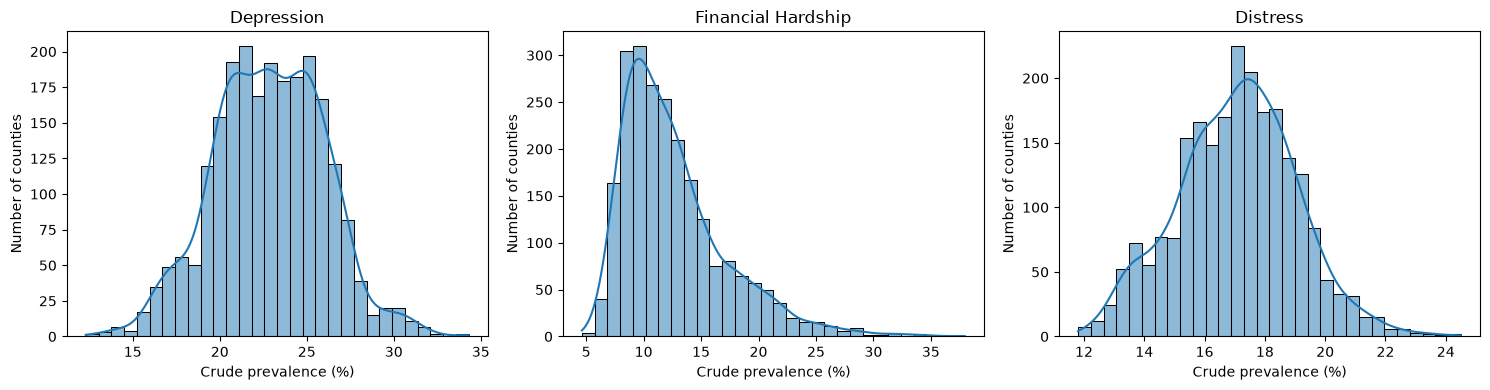

In [23]:
plot_columns = [
    "depression",
    "financial_hardship",
    "distress",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, axis in zip(plot_columns, axes):
    sns.histplot(
        data=county_complete,
        x=column,
        bins=30,
        kde=True,
        ax=axis,
    )
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("Crude prevalence (%)")
    axis.set_ylabel("Number of counties")

plt.tight_layout()
plt.show()

In [24]:
correlation_columns = [
    "depression",
    "housing",
    "utility",
    "food",
    "stamps",
    "financial_hardship",
    "distress",
]

correlations = (
    county_complete[correlation_columns]
    .corr()
    .round(3)
)

correlations

,depression,housing,utility,food,stamps,financial_hardship,distress
depression,1.000,-0.023,0.121,0.024,0.167,0.075,0.635
housing,-0.023,1.000,0.957,0.980,0.884,0.978,0.630
utility,0.121,0.957,1.000,0.965,0.892,0.974,0.712
food,0.024,0.980,0.965,1.000,0.904,0.988,0.643
stamps,0.167,0.884,0.892,0.904,1.000,0.952,0.686
financial_hardship,0.075,0.978,0.974,0.988,0.952,1.000,0.683
distress,0.635,0.630,0.712,0.643,0.686,0.683,1.000


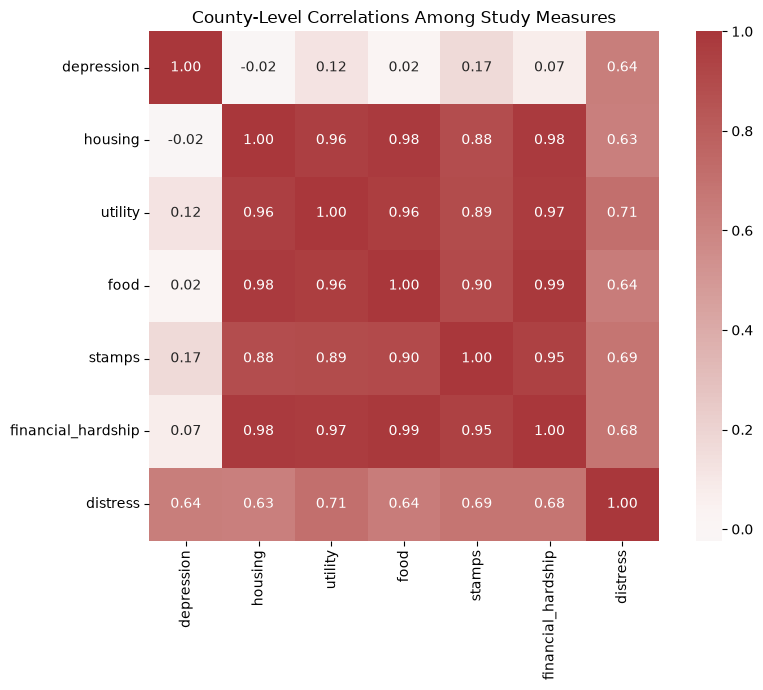

In [25]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
)

plt.title("County-Level Correlations Among Study Measures")
plt.tight_layout()
plt.show()

### Preliminary findings

Frequent mental distress was positively correlated with both depression
prevalence (r = 0.64) and the financial-hardship composite (r = 0.68).

Depression and financial hardship were only weakly correlated with each
other (r = 0.07). This suggests that they may capture distinct county-level
dimensions associated with mental distress and may provide complementary
predictive information.

The four financial components were highly intercorrelated (r = 0.88–0.98).
Consequently, they are represented by one composite rather than entered
simultaneously as separate regression predictors. This avoids severe
multicollinearity and preserves the original study's conceptual approach.

These correlations describe county-level geographic associations and should
not be interpreted as individual-level or causal relationships.

## 5. Predictive Model Comparison

Three linear-regression models are compared:

1. Depression prevalence only
2. Financial hardship only
3. Depression prevalence and financial hardship together

Evaluation uses leave-one-jurisdiction-out cross-validation. Every county is
predicted by a model that was not trained on any county from its state or
jurisdiction. This provides a more rigorous test than randomly dividing
counties from the same states between training and testing.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [27]:
model_features = {
    "Depression only": [
        "depression",
    ],
    "Financial hardship only": [
        "financial_hardship",
    ],
    "Combined": [
        "depression",
        "financial_hardship",
    ],
}

y = county_complete["distress"]
groups = county_complete["StateAbbr"]

logo = LeaveOneGroupOut()

print("Counties:", len(county_complete))
print("Jurisdictions:", groups.nunique())
print("Cross-validation folds:", logo.get_n_splits(groups=groups))

Counties: 2299
Jurisdictions: 40
Cross-validation folds: 40


In [28]:
comparison_rows = []
cv_predictions = {}

for model_name, features in model_features.items():
    X = county_complete[features]

    predictions = cross_val_predict(
        estimator=LinearRegression(),
        X=X,
        y=y,
        groups=groups,
        cv=logo,
    )

    cv_predictions[model_name] = predictions

    comparison_rows.append({
        "Model": model_name,
        "Predictors": ", ".join(features),
        "R2": r2_score(y, predictions),
        "RMSE": mean_squared_error(
            y,
            predictions,
        ) ** 0.5,
        "MAE": mean_absolute_error(
            y,
            predictions,
        ),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_comparison[["R2", "RMSE", "MAE"]] = (
    model_comparison[["R2", "RMSE", "MAE"]].round(3)
)

model_comparison

,Model,Predictors,R2,RMSE,MAE
0,Combined,"depression, financial_hardship",0.790,0.908,0.734
1,Financial hardship only,financial_hardship,0.432,1.493,1.156
2,Depression only,depression,0.350,1.597,1.240


In [29]:
results_by_model = model_comparison.set_index("Model")

depression_rmse = results_by_model.loc[
    "Depression only", "RMSE"
]
financial_rmse = results_by_model.loc[
    "Financial hardship only", "RMSE"
]
combined_rmse = results_by_model.loc[
    "Combined", "RMSE"
]

print(
    "Combined-model RMSE improvement over depression only:",
    f"{depression_rmse - combined_rmse:.3f} percentage points",
)

print(
    "Combined-model RMSE improvement over financial hardship only:",
    f"{financial_rmse - combined_rmse:.3f} percentage points",
)

Combined-model RMSE improvement over depression only: 0.689 percentage points
Combined-model RMSE improvement over financial hardship only: 0.585 percentage points


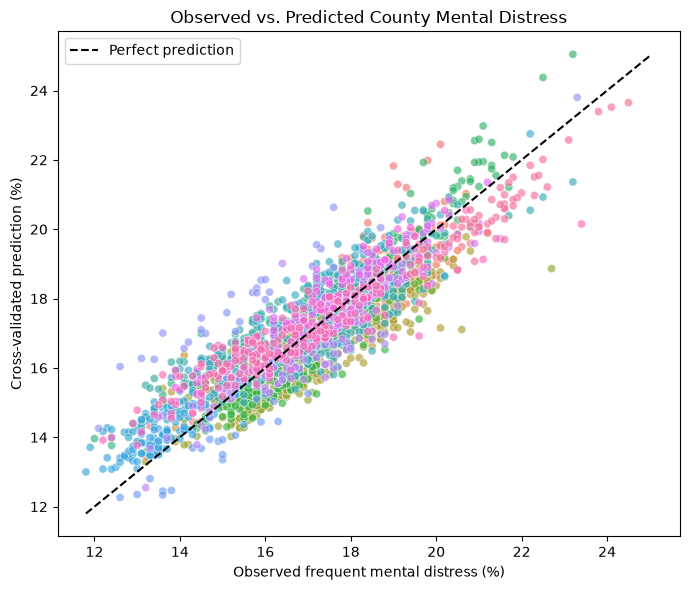

In [30]:
county_complete["combined_cv_prediction"] = (
    cv_predictions["Combined"]
)

minimum = min(
    county_complete["distress"].min(),
    county_complete["combined_cv_prediction"].min(),
)

maximum = max(
    county_complete["distress"].max(),
    county_complete["combined_cv_prediction"].max(),
)

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=county_complete,
    x="distress",
    y="combined_cv_prediction",
    hue="StateAbbr",
    legend=False,
    alpha=0.65,
    s=35,
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    color="black",
    label="Perfect prediction",
)

plt.xlabel("Observed frequent mental distress (%)")
plt.ylabel("Cross-validated prediction (%)")
plt.title("Observed vs. Predicted County Mental Distress")
plt.legend()
plt.tight_layout()
plt.show()

### Cross-validated model comparison

The combined model substantially outperformed both single-predictor models
under leave-one-jurisdiction-out cross-validation.

The combined model achieved an R² of 0.790, RMSE of 0.908 percentage points,
and MAE of 0.734 percentage points. Relative to the depression-only model,
adding financial hardship reduced RMSE by 0.689 percentage points,
approximately 43.1%. Relative to the financial-hardship-only model, adding
depression reduced RMSE by 0.585 percentage points, approximately 39.2%.

These findings support the predictive hypothesis that depression prevalence
and financial hardship provide complementary county-level information about
frequent mental distress. They do not demonstrate that either predictor
causes mental distress.

In [31]:
state_metric_rows = []

for model_name, predictions in cv_predictions.items():
    temporary = county_complete[
        ["StateAbbr", "distress"]
    ].copy()

    temporary["prediction"] = predictions
    temporary["absolute_error"] = (
        temporary["distress"] - temporary["prediction"]
    ).abs()
    temporary["squared_error"] = (
        temporary["distress"] - temporary["prediction"]
    ) ** 2

    state_metrics = (
        temporary
        .groupby("StateAbbr")
        .agg(
            counties=("distress", "size"),
            MAE=("absolute_error", "mean"),
            MSE=("squared_error", "mean"),
        )
        .reset_index()
    )

    state_metrics["RMSE"] = np.sqrt(state_metrics["MSE"])
    state_metrics["Model"] = model_name

    state_metric_rows.append(state_metrics)

state_metrics = pd.concat(
    state_metric_rows,
    ignore_index=True,
)

state_balanced_comparison = (
    state_metrics
    .groupby("Model")
    .agg(
        mean_state_RMSE=("RMSE", "mean"),
        median_state_RMSE=("RMSE", "median"),
        mean_state_MAE=("MAE", "mean"),
        median_state_MAE=("MAE", "median"),
    )
    .sort_values("mean_state_RMSE")
    .round(3)
)

state_balanced_comparison

,mean_state_RMSE,median_state_RMSE,mean_state_MAE,median_state_MAE
Model,,,,
Combined,0.918,0.846,0.791,0.665
Financial hardship only,1.492,1.330,1.277,1.073
Depression only,1.521,1.500,1.287,1.208


### Final fitted equation

After cross-validation, the combined linear regression was fitted to the full
complete-case dataset:

$$
\widehat{\text{Mental Distress}}
=
5.271
+
0.364(\text{Depression})
+
0.276(\text{Financial Hardship})
$$
Holding financial hardship constant, a one-percentage-point increase in
county depression prevalence was associated with a 0.364 percentage-point
increase in predicted frequent mental distress. Holding depression constant,
a one-percentage-point increase in financial hardship was associated with a
0.276 percentage-point increase in predicted distress.

The intercept should not receive a substantive interpretation because zero
values for both predictors fall outside the observed county data. The
coefficients describe adjusted county-level associations, not causal or
individual-level effects.

In [34]:
combined_state_metrics = (
    state_metrics[
        state_metrics["Model"].eq("Combined")
    ]
    .sort_values("RMSE", ascending=False)
)

combined_state_metrics.head(10)

,StateAbbr,counties,MAE,MSE,RMSE,Model
109,NM,33,2.148782,5.236791,2.288404,Combined
86,DC,1,2.269124,5.148922,2.269124,Combined
110,NV,17,1.177225,1.710379,1.307815,Combined
88,GA,159,1.120845,1.584298,1.258689,Combined
100,MN,87,1.140216,1.520234,1.232978,Combined
105,ND,53,1.115679,1.460887,1.208671,Combined
108,NJ,21,1.106104,1.407572,1.186411,Combined
104,NC,100,1.009853,1.221675,1.105294,Combined
114,RI,5,0.927426,1.115762,1.056296,Combined
96,MA,14,0.931445,1.090136,1.044096,Combined


In [35]:
combined_not_better_than_depression = (
    state_rmse_wide[
        state_rmse_wide["Combined"]
        >= state_rmse_wide["Depression only"]
    ]
    .sort_values("Combined", ascending=False)
)

combined_not_better_than_financial = (
    state_rmse_wide[
        state_rmse_wide["Combined"]
        >= state_rmse_wide["Financial hardship only"]
    ]
    .sort_values("Combined", ascending=False)
)

print("Combined did not beat depression-only:")
display(combined_not_better_than_depression)

print("Combined did not beat financial-only:")
display(combined_not_better_than_financial)

Combined did not beat depression-only:


Model,Combined,Depression only,Financial hardship only
StateAbbr,,,
NM,2.288404,1.967711,2.789523
IA,1.011575,0.514060,0.465153
HI,0.959635,0.326366,2.938570
KS,0.839130,0.782203,0.781491


Combined did not beat financial-only:


Model,Combined,Depression only,Financial hardship only
StateAbbr,,,
NV,1.307815,1.740692,0.994171
GA,1.258689,2.671120,1.094815
MN,1.232978,2.299599,0.968247
NC,1.105294,1.527973,0.948179
RI,1.056296,2.326672,0.942854
WI,1.040530,1.912245,1.014803
IA,1.011575,0.514060,0.465153
KS,0.839130,0.782203,0.781491


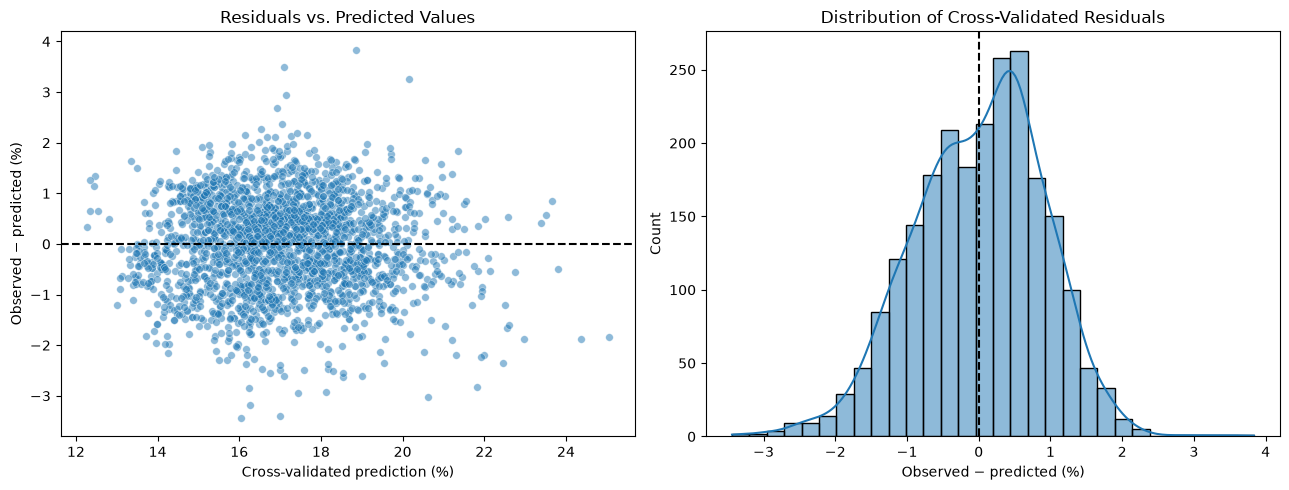

In [36]:
county_complete["combined_cv_residual"] = (
    county_complete["distress"]
    - county_complete["combined_cv_prediction"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=county_complete,
    x="combined_cv_prediction",
    y="combined_cv_residual",
    alpha=0.5,
    s=30,
    ax=axes[0],
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
)

axes[0].set_title("Residuals vs. Predicted Values")
axes[0].set_xlabel("Cross-validated prediction (%)")
axes[0].set_ylabel("Observed − predicted (%)")

sns.histplot(
    data=county_complete,
    x="combined_cv_residual",
    bins=30,
    kde=True,
    ax=axes[1],
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
)

axes[1].set_title("Distribution of Cross-Validated Residuals")
axes[1].set_xlabel("Observed − predicted (%)")

plt.tight_layout()
plt.show()

In [37]:
county_complete["combined_cv_residual"].describe().round(3)

count    2299.000
mean        0.008
std         0.909
min        -3.440
25%        -0.607
50%         0.069
75%         0.637
max         3.836
Name: combined_cv_residual, dtype: float64

In [38]:
state_bias = (
    county_complete
    .groupby("StateAbbr")
    .agg(
        counties=("LocationID", "size"),
        mean_residual=("combined_cv_residual", "mean"),
        mean_absolute_residual=(
            "combined_cv_residual",
            lambda values: values.abs().mean(),
        ),
    )
    .sort_values(
        "mean_absolute_residual",
        ascending=False,
    )
)

state_bias.head(10)

,counties,mean_residual,mean_absolute_residual
StateAbbr,,,
DC,1,-2.269124,2.269124
NM,33,-2.148782,2.148782
NV,17,1.151382,1.177225
MN,87,-1.140216,1.140216
GA,159,1.104083,1.120845
ND,53,-1.105458,1.115679
NJ,21,1.106104,1.106104
NC,100,-0.971454,1.009853
IA,99,0.960643,0.960643


### Residual diagnostics and geographic variation

Cross-validated residuals were centered near zero (mean = 0.008 percentage
points), indicating little overall directional bias. Their standard deviation
was approximately 0.91 percentage points.

Performance nevertheless varied across jurisdictions. The combined model
systematically overpredicted counties in some states, particularly New Mexico,
and underpredicted counties in others, including Nevada and Georgia. The
combined model did not outperform depression alone in four jurisdictions and
did not outperform financial hardship alone in eight jurisdictions.

Thus, the combined model provided the strongest overall and state-balanced
performance, but its accuracy was not uniform across jurisdictions. This
variation suggests that additional state-level context or regional factors may
be relevant. The District of Columbia result should be interpreted cautiously
because it contains only one county-equivalent observation.

In [40]:
import statsmodels.api as sm

X_inference = county_complete[
    [
        "depression",
        "financial_hardship",
    ]
]

X_inference = sm.add_constant(X_inference)

clustered_model = sm.OLS(
    county_complete["distress"],
    X_inference,
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": county_complete["StateAbbr"],
    },
)

clustered_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               distress   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     190.0
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           7.80e-21
Time:                        16:20:12   Log-Likelihood:                -2927.2
No. Observations:                2299   AIC:                             5860.
Df Residuals:                    2296   BIC:                             5878.
Df Model:                           2                                         
Covariance Type:              cluster                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.2708      0.717      7.347      0.000       3.865       6.677
depression             0.3638      0.029     12.485      0.000       0.307       0.421
financial_hardship     0.2763      0.020     13.585      0.000       0.236       0.316
==============================================================================
Omnibus:                       34.205   Durbin-Watson:                   0.857
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.111
Skew:                          -0.252   Prob(JB):                     5.30e-09
Kurtosis:                       3.378   Cond. No.                         200.
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [41]:
confidence_intervals = clustered_model.conf_int()

coefficient_table = pd.DataFrame({
    "coefficient": clustered_model.params,
    "clustered_standard_error": clustered_model.bse,
    "p_value": clustered_model.pvalues,
    "ci_lower_95": confidence_intervals[0],
    "ci_upper_95": confidence_intervals[1],
}).round(4)

coefficient_table

,coefficient,clustered_standard_error,p_value,ci_lower_95,ci_upper_95
const,5.2708,0.7174,0.0,3.8646,6.6769
depression,0.3638,0.0291,0.0,0.3067,0.4209
financial_hardship,0.2763,0.0203,0.0,0.2364,0.3161


## 6. Cluster-Robust Statistical Inference

The final combined model was estimated using ordinary least squares with
standard errors clustered by state. Clustered standard errors account for the
fact that counties within the same state may share policies, demographics,
survey procedures, regional conditions, and other unmeasured characteristics.

Both predictors retained positive adjusted county-level associations with
frequent mental distress:

- Depression: b = 0.364, cluster-robust SE = 0.029,
  95% CI [0.307, 0.421], p < .001.
- Financial hardship: b = 0.276, cluster-robust SE = 0.020,
  95% CI [0.236, 0.316], p < .001.

The model fitted to the complete dataset explained approximately 81.0% of the
county-level variation in frequent mental distress (R² = 0.810; adjusted
R² = 0.809). Leave-one-jurisdiction-out cross-validation produced a slightly
lower R² of 0.790, as expected when evaluating predictions on jurisdictions
excluded from model training.

These results indicate that depression and financial hardship each contribute
distinct predictive information. Because the study is cross-sectional and
ecological, the coefficients should not be interpreted as causal effects or
as relationships between individual people.

In [42]:
from sklearn.preprocessing import StandardScaler

standardized_data = county_complete[
    [
        "depression",
        "financial_hardship",
        "distress",
    ]
].copy()

standardized_data[
    [
        "depression",
        "financial_hardship",
        "distress",
    ]
] = StandardScaler().fit_transform(
    standardized_data[
        [
            "depression",
            "financial_hardship",
            "distress",
        ]
    ]
)

X_standardized = sm.add_constant(
    standardized_data[
        [
            "depression",
            "financial_hardship",
        ]
    ]
)

standardized_model = sm.OLS(
    standardized_data["distress"],
    X_standardized,
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": county_complete["StateAbbr"],
    },
)

standardized_coefficient_table = pd.DataFrame({
    "standardized_coefficient": standardized_model.params,
    "clustered_standard_error": standardized_model.bse,
    "p_value": standardized_model.pvalues,
}).round(4)

standardized_coefficient_table

,standardized_coefficient,clustered_standard_error,p_value
const,-0.0000,0.0639,1.0
depression,0.5869,0.0470,0.0
financial_hardship,0.6393,0.0471,0.0


### Standardized effect comparison

After standardizing the outcome and predictors, both depression and financial
hardship remained strongly associated with county mental distress.

A one-standard-deviation increase in depression prevalence was associated
with a 0.587-standard-deviation increase in frequent mental distress,
holding financial hardship constant. A one-standard-deviation increase in
financial hardship was associated with a 0.639-standard-deviation increase
in distress, holding depression constant. Both associations had
cluster-robust p-values below .001.

The standardized coefficient for financial hardship was numerically larger,
but the two coefficients were similar in magnitude. No claim is made that
their strengths differ statistically without a formal coefficient-difference
test.

## 7. Conclusion

This county-level extension found that depression prevalence and financial
hardship provide complementary information for predicting frequent mental
distress.

Among 2,299 counties across 39 states and the District of Columbia, the
combined linear model substantially outperformed models using either
predictor alone. Under leave-one-jurisdiction-out cross-validation, the
combined model achieved an R² of 0.790, RMSE of 0.908 percentage points, and
MAE of 0.734 percentage points.

The final fitted equation was:

$$
\widehat{\text{Mental Distress}}
=
5.271
+
0.364(\text{Depression})
+
0.276(\text{Financial Hardship})
$$

Both adjusted associations remained statistically distinguishable from zero
when standard errors were clustered by state. Model performance nevertheless
varied across jurisdictions, indicating that additional state, regional, or
local factors may influence mental distress.

The findings support the predictive hypothesis at the county level but do not
establish causality or individual-level relationships.

## 8. Limitations

1. **Cross-sectional design:** The data describe one release period and cannot
   establish temporal order or causality.

2. **Ecological analysis:** Counties, not individual people, are the units of
   analysis. County-level relationships must not be interpreted as
   individual-level effects.

3. **Modeled estimates:** CDC PLACES values are model-based small-area
   estimates rather than direct county survey estimates.

4. **Incomplete geographic coverage:** Financial-hardship measures were
   available for only 39 states and the District of Columbia. Kentucky,
   Pennsylvania, and nine additional states were not represented in the final
   combined analysis.

5. **Study-defined composite:** The financial-hardship measure is an equally
   weighted average of four indicators and has not been established as an
   independently validated scale.

6. **Equal county weighting:** Each county contributes equally regardless of
   population size. The results therefore characterize relationships across
   counties rather than across individual U.S. adults.

7. **Geographic dependence:** Counties may resemble nearby counties beyond
   their shared state membership. Clustered standard errors address
   within-state dependence but do not fully model spatial autocorrelation.

8. **Uneven state performance:** The combined model performed best overall but
   did not outperform both reduced models in every jurisdiction.

9. **Unmeasured variables:** Demographics, healthcare access, urbanicity,
   employment, policy, and other contextual factors were not included.

10. **Prediction versus intervention:** Strong predictive performance does not
    show that changing either predictor would necessarily change mental
    distress by the corresponding coefficient.